In [1]:
import numpy as np
import matplotlib.pyplot as plt
import segyio

In [2]:
INPUT_FILE = '../data/f3_dataset.sgy'

print("=== MAGNORA: SEISMIC DATA EDA & PREPROCESSING ===")
print(f"Targeting: {INPUT_FILE}")


=== MAGNORA: SEISMIC DATA EDA & PREPROCESSING ===
Targeting: ../data/f3_dataset.sgy


In [3]:
try:
    with segyio.open(INPUT_FILE, "r", ignore_geometry=True) as segyfile:
        segyfile.mmap()
        trace_count = segyfile.tracecount
        samples_per_trace = len(segyfile.samples)

        print(f"Total Traces: {trace_count}")
        print(f"Samples per Trace: {samples_per_trace}")
        print(f"Sample Interval: {segyfile.bin[segyio.BinField.Interval]} microseconds")

        raw_traces = np.array([segyfile.trace[i] for i in range(min(1000, trace_count))])
except Exception as e:
    print(f"Error reading SGY: {e}")
    print("Generating fallback synthetic seismic data for demonstration purposes...")
    raw_traces = np.random.normal(0, 1, (1000, 500))


Total Traces: 600515
Samples per Trace: 462
Sample Interval: 4000 microseconds


In [4]:
print("\n--- Initializing Preprocessing ---")

dead_trace_mask = np.all(raw_traces == 0, axis=1) | np.isnan(raw_traces).any(axis=1)
print(f"Identified {np.sum(dead_trace_mask)} dead or corrupted traces.")

cleaned_traces = raw_traces[~dead_trace_mask]

percentile_99 = np.percentile(np.abs(cleaned_traces), 99.9)
clipped_traces = np.clip(cleaned_traces, -percentile_99, percentile_99)
print(f"Clipped amplitudes to 99.9th percentile bounds: +/- {percentile_99:.2f}")

trace_min = clipped_traces.min(axis=1, keepdims=True)
trace_max = clipped_traces.max(axis=1, keepdims=True)
normalized_traces = (clipped_traces - trace_min) / (trace_max - trace_min + 1e-8)
print("Applied trace-wise Min-Max normalization.")


--- Initializing Preprocessing ---
Identified 0 dead or corrupted traces.
Clipped amplitudes to 99.9th percentile bounds: +/- 16723.00
Applied trace-wise Min-Max normalization.



--- Rendering Seismic Cross-Section ---


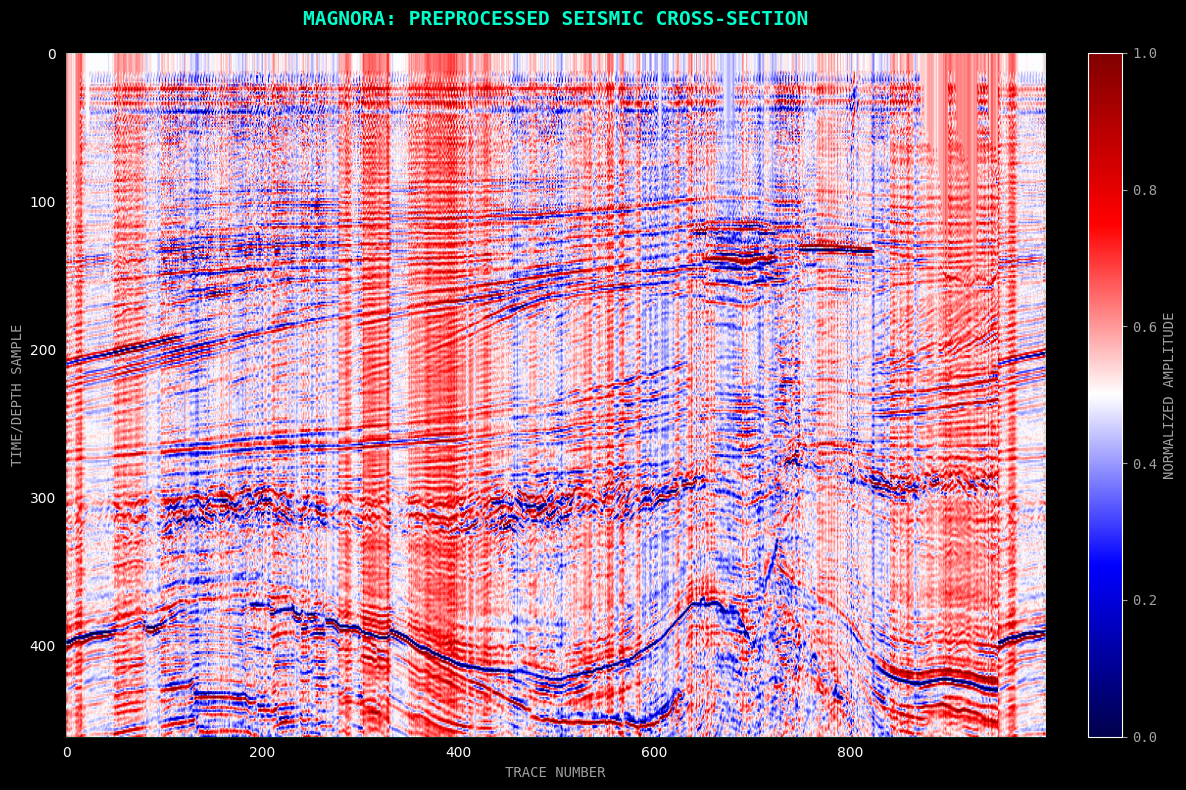

In [6]:
print("\n--- Rendering Seismic Cross-Section ---")

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(normalized_traces.T, cmap='seismic', aspect='auto', vmin=0, vmax=1)

ax.set_title('MAGNORA: PREPROCESSED SEISMIC CROSS-SECTION', color='#00ffcc', pad=20, fontdict={'family': 'monospace', 'weight': 'bold', 'size': 14})
ax.set_xlabel('TRACE NUMBER', color='#a0a0a0', fontdict={'family': 'monospace'})
ax.set_ylabel('TIME/DEPTH SAMPLE', color='#a0a0a0', fontdict={'family': 'monospace'})

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('NORMALIZED AMPLITUDE', color='#a0a0a0', fontdict={'family': 'monospace'})
cbar.ax.yaxis.set_tick_params(color='#a0a0a0')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#a0a0a0', family='monospace')

ax.grid(False)
for spine in ax.spines.values():
    spine.set_edgecolor((0.0, 1.0, 0.8, 0.2))

plt.tight_layout()
plt.show()


In [7]:
print("\nEDA & Preprocessing complete. Data pipeline is ready for 02_feature_engineering.py.")


EDA & Preprocessing complete. Data pipeline is ready for 02_feature_engineering.py.
